# Multimodal Emotion Recognition — Feature Fusion

Three-part experiment combining audio and text for emotion classification on MELD.

## Model selection
The audio model is chosen via **complementarity analysis** (section 1c): each model is scored by how strongly it performs on the emotion classes where the text model is weakest, with `neutral` excluded to avoid majority-class bias. The winner (`audio_mlp_egemaps`) is used as the audio branch.

## Pipeline

| Input | Source | Dims |
|---|---|---|
| Audio softmax | Best complementary audio model (from section 1c) | 8 |
| Text CLS (scaled) | Fine-tuned RoBERTa + StandardScaler | 768 |
| **Fused (MLP)** | Concatenation → 2-layer MLP | **776** |

## Late fusion — ceiling check
A weighted average of audio and text softmax (proportional to dev macro-F1) is evaluated as an upper-bound reference. If even this blend does not beat text alone, it confirms that audio and text carry **no complementary information** in this dataset.

In [1]:
import sys, json, pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Dataset as TorchDataset
from torch.optim import AdamW
from tqdm.auto import tqdm
import optuna
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score
from transformers import AutoModelForSequenceClassification, RobertaTokenizer

SRC = Path('../src').resolve()
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from config import (
    FEATURES_DIR, CHECKPOINTS_DIR, METRICS_DIR, PREDICTIONS_DIR, OUTPUTS_DIR,
    EMOTION_LABELS, NUM_CLASSES, RANDOM_SEED, FEATURE_SETS,
    audio_tag, multimodal_tag, get_model_path, get_scaler_path,
    get_hparams_path, get_metrics_path, get_prediction_path,
)
from evaluate import evaluate_and_save

for d in (CHECKPOINTS_DIR, METRICS_DIR, PREDICTIONS_DIR, OUTPUTS_DIR / 'plots'):
    d.mkdir(parents=True, exist_ok=True)

# ── Configuration ─────────────────────────────────────────────────────────────
AUDIO_FEATURE_SET  = 'is10'           # IS10 parquet used for data alignment
BEST_TRIAL         = '5'
ROBERTA_MODELS_DIR = Path('../data/models')

# Feature-concatenation MLP  (audio softmax ‖ CLS embeddings → MLP)
TAG      = multimodal_tag('feature_fusion')   # "multimodal_feature_fusion"
# Late fusion weighted average  (w*audio_softmax + (1-w)*text_softmax)
LATE_TAG = multimodal_tag('late_fusion')      # "multimodal_late_fusion"

# Audio model selected by complementarity analysis (section 1c):
# highest weighted score on minority emotion classes (neutral excluded).
BEST_AUDIO_TAG = audio_tag('mlp', 'egemaps')

# Best hyperparameters from text Optuna search (Trial 5)
ROBERTA_BEST_PARAMS = {
    'learning_rate':               8.195663562822106e-06,
    'per_device_train_batch_size': 8,
    'num_train_epochs':            4,
    'weight_decay':                0.07960545199184652,
}

torch.manual_seed(RANDOM_SEED)
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style='whitegrid')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device         : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU            : {torch.cuda.get_device_name(0)}')
print(f'Fusion MLP tag : {TAG}')
print(f'Late fusion tag: {LATE_TAG}')
print(f'Audio model    : {BEST_AUDIO_TAG}')

Device         : cpu
Fusion MLP tag : multimodal_feature_fusion
Late fusion tag: multimodal_late_fusion
Audio model    : audio_mlp_egemaps


## 1 · Load & Align Data

Reads the manifest CSVs (built by `build_manifest.py`) for each split, constructs the **context-linked text** column (same logic as `text_experiments.ipynb`: prepend previous utterance with `</s>` separator), then inner-joins with the IS10 audio feature parquets on `(dialogue_id, utterance_id)`.

In [2]:
MANIFEST_DIR = Path('../data/processed')

# text_experiments.ipynb saves pre-built text_with_context here (note: 'val' for dev split)
_PROC_CSV = {
    'train': MANIFEST_DIR / 'train_processed.csv',
    'dev':   MANIFEST_DIR / 'val_processed.csv',
    'test':  MANIFEST_DIR / 'test_processed.csv',
}

def build_context(row):
    prev = row['prev_text']
    return (prev + ' </s> ' + row['text']) if prev != '' else row['text']

def load_manifest(split):
    proc = _PROC_CSV[split]
    if proc.exists():
        # Use the exact text_with_context saved by text_experiments.ipynb
        df = pd.read_csv(proc, usecols=['dialogue_id', 'utterance_id', 'text_with_context'])
        print(f'  {split:5s}: text_with_context from {proc.name}')
        return df[['dialogue_id', 'utterance_id', 'text_with_context']]
    else:
        # Fall back: build context from manifest CSV
        df = pd.read_csv(MANIFEST_DIR / f'manifest_{split}.csv')
        df['prev_text'] = df.groupby('dialogue_id')['text'].shift(1).fillna('')
        df['text_with_context'] = df.apply(build_context, axis=1)
        print(f'  {split:5s}: text_with_context built from manifest_{split}.csv')
        return df[['dialogue_id', 'utterance_id', 'text_with_context']]

def load_aligned(split):
    manifest = load_manifest(split)
    audio_df = pd.read_parquet(FEATURES_DIR / f'{split}_{AUDIO_FEATURE_SET}.parquet')
    audio_df = audio_df.dropna().reset_index(drop=True)
    merged   = audio_df.merge(manifest, on=['dialogue_id', 'utterance_id'], how='inner')
    missed   = len(audio_df) - len(merged)
    if missed:
        print(f'  [WARN] {split}: {missed} audio rows had no text match (dropped)')
    print(f'  {split:5s}: {len(merged):,} aligned utterances')
    return merged

print('Loading manifests:')
train_df = load_aligned('train')
dev_df   = load_aligned('dev')
test_df  = load_aligned('test')

ID_COLS    = {'dialogue_id', 'utterance_id', 'label_idx', 'text_with_context'}
AUDIO_COLS = [c for c in train_df.columns if c not in ID_COLS]
print(f'\nAudio feature dims : {len(AUDIO_COLS)}')
print(f'Sample (train[0])  : {train_df["text_with_context"].iloc[0][:80]!r}')

Loading manifests:
  train: text_with_context from train_processed.csv
  train: 9,982 aligned utterances
  dev  : text_with_context from val_processed.csv
  dev  : 1,106 aligned utterances
  test : text_with_context from test_processed.csv
  test : 2,610 aligned utterances

Audio feature dims : 1582
Sample (train[0])  : "also I was the point person on my company's transition from the KL-5 to GR-6 sys"


### 1b · Ensure Audio Baseline (LR + IS10)

Checks whether `audio_lr_is10` has already been trained. If not, runs it using the pre-saved best hyperparameters from `config.py` (`--no-optimize`) — takes ~30 s on CPU.

In [3]:
from audio.lr.train import main as _train_audio_lr

_audio_is10_metrics = get_metrics_path(audio_tag('lr', 'is10'))

if _audio_is10_metrics.exists():
    _m = json.loads(_audio_is10_metrics.read_text())
    print('Audio LR IS10 already trained:')
    print(f'  Test macro-F1    : {_m["macro_f1"]:.4f}')
    print(f'  Test weighted-F1 : {_m["weighted_f1"]:.4f}')
else:
    print('Audio LR IS10 not found — training now (saved best params, no Optuna search)...')
    _train_audio_lr('is10', optimize=False)
    print('Audio LR IS10 training complete.')

Audio LR IS10 already trained:
  Test macro-F1    : 0.1732
  Test weighted-F1 : 0.2479


### 1c · Select Best Complementary Audio Model

Ranks all audio models by **complementarity score** — which model helps the text model the most on the classes where it struggles.

**Score** = audio F1 weighted by `(1 − text_F1)` per class, averaged over the 7 minority classes (neutral excluded). A class where text scores 0.24 (fear) counts roughly 3× more than one where it scores 0.57 (joy), so the ranking directly rewards audio models that are strong exactly where text is weakest.

Two views are shown side by side:
- **Absolute F1**: raw per-class performance of text and all audio models
- **Delta F1 = audio − text**: where audio beats text (blue) vs. where it falls behind (red)

> Requires `text_roberta.json` (run section 8 first on a fresh notebook).

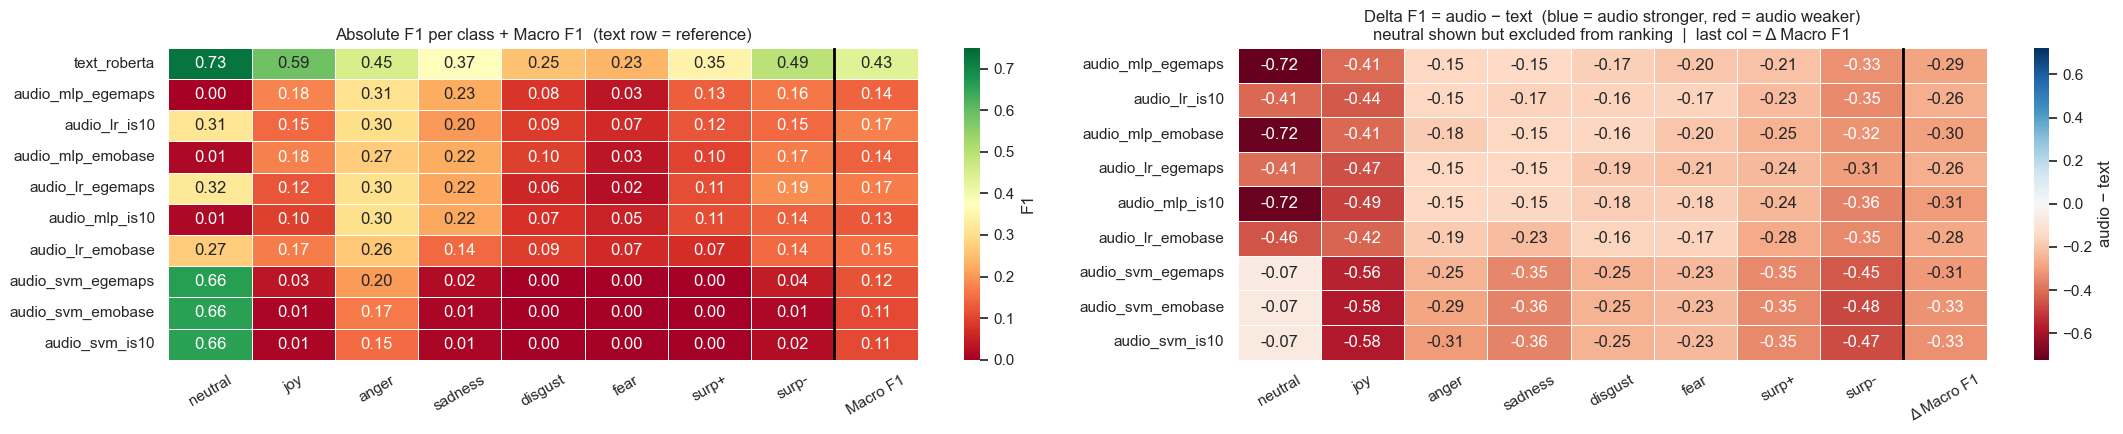

Ranking by complementarity score (neutral excluded):
Score = audio F1 weighted by (1 − text_F1) — classes where text struggles most count most.

  Model                                Comp score  Macro F1
  -----------------------------------  ----------  --------
  audio_mlp_egemaps                        0.1498    0.1405  ← selected
  audio_lr_is10                            0.1460    0.1732
  audio_mlp_emobase                        0.1432    0.1353
  audio_lr_egemaps                         0.1379    0.1690
  audio_mlp_is10                           0.1363    0.1256
  audio_lr_emobase                         0.1283    0.1534
  audio_svm_egemaps                        0.0373    0.1201
  audio_svm_emobase                        0.0251    0.1067
  audio_svm_is10                           0.0239    0.1058

Selected : audio_mlp_egemaps
Score    : 0.1498


In [4]:
_ALL_AUDIO_TAGS = [
    audio_tag('lr',  'is10'),
    audio_tag('lr',  'egemaps'),
    audio_tag('lr',  'emobase'),
    audio_tag('svm', 'egemaps'),
    audio_tag('svm', 'emobase'),
    audio_tag('svm', 'is10'),
    audio_tag('mlp', 'egemaps'),
    audio_tag('mlp', 'emobase'),
    audio_tag('mlp', 'is10'),
]
_SHORT = {
    'neutral': 'neutral', 'joy': 'joy', 'anger': 'anger',
    'sadness': 'sadness', 'disgust': 'disgust', 'fear': 'fear',
    'surprise_positive': 'surp+', 'surprise_negative': 'surp-',
}
_SCORE_CLASSES = [c for c in EMOTION_LABELS if c != 'neutral']

_text_p = get_metrics_path('text_roberta')
if not _text_p.exists():
    print('text_roberta.json not found — run section 8 first, then re-run this cell.')
    print(f'BEST_AUDIO_TAG stays: {BEST_AUDIO_TAG}  (set in cc01)')
else:
    _tm          = json.loads(_text_p.read_text())
    _tf1         = {c: _tm['per_class'][c]['f1'] for c in EMOTION_LABELS}
    _text_macro  = _tm['macro_f1']
    _tweak       = np.array([1 - _tf1[c] for c in _SCORE_CLASSES])

    # ── Collect per-class F1 for every audio model ────────────────────────────
    _rows = []
    for tag in _ALL_AUDIO_TAGS:
        p = get_metrics_path(tag)
        if not p.exists():
            continue
        m   = json.loads(p.read_text())
        row = {'model': tag, 'macro_f1_all': m['macro_f1']}
        for c in EMOTION_LABELS:
            row[c] = m['per_class'][c]['f1']
        af1 = np.array([m['per_class'][c]['f1'] for c in _SCORE_CLASSES])
        row['comp_score'] = float((af1 * _tweak).sum() / _tweak.sum())
        _rows.append(row)

    _df = (pd.DataFrame(_rows)
             .set_index('model')
             .sort_values('comp_score', ascending=False))
    BEST_AUDIO_TAG = _df.index[0]

    # ── Build DataFrames — per-class columns + Macro F1 summary column ────────
    _abs_rows, _delta_rows = [], []
    for tag, row in _df.iterrows():
        _abs_rows.append({
            'model': tag,
            **{_SHORT[c]: row[c] for c in EMOTION_LABELS},
            'Macro F1': row['macro_f1_all'],
        })
        _delta_rows.append({
            'model': tag,
            **{_SHORT[c]: row[c] - _tf1[c] for c in EMOTION_LABELS},
            'Δ Macro F1': row['macro_f1_all'] - _text_macro,
        })

    _text_row = {
        'model': 'text_roberta',
        **{_SHORT[c]: _tf1[c] for c in EMOTION_LABELS},
        'Macro F1': _text_macro,
    }
    _abs_df   = pd.DataFrame([_text_row] + _abs_rows).set_index('model')
    _delta_df = pd.DataFrame(_delta_rows).set_index('model')

    # ── Plots ─────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(22, 4.5))

    # Left: absolute F1 — per-class + Macro F1 column
    sns.heatmap(
        _abs_df, annot=True, fmt='.2f', cmap='RdYlGn',
        vmin=0.0, vmax=0.75, linewidths=0.4, ax=axes[0],
        cbar_kws={'label': 'F1'},
    )
    # Vertical line separating per-class from macro summary
    axes[0].axvline(x=len(EMOTION_LABELS), color='black', linewidth=2)
    axes[0].set_title('Absolute F1 per class + Macro F1  (text row = reference)')
    axes[0].set_xlabel(''); axes[0].set_ylabel('')
    axes[0].tick_params(axis='x', rotation=30)

    # Right: delta F1 = audio − text — per-class + Δ Macro F1
    _vmax = max(abs(_delta_df.values.min()), abs(_delta_df.values.max()))
    sns.heatmap(
        _delta_df, annot=True, fmt='+.2f', cmap='RdBu',
        vmin=-_vmax, vmax=_vmax, center=0,
        linewidths=0.4, ax=axes[1],
        cbar_kws={'label': 'audio − text'},
    )
    axes[1].axvline(x=len(EMOTION_LABELS), color='black', linewidth=2)
    axes[1].set_title(
        'Delta F1 = audio − text  (blue = audio stronger, red = audio weaker)\n'
        'neutral shown but excluded from ranking  |  last col = Δ Macro F1'
    )
    axes[1].set_xlabel(''); axes[1].set_ylabel('')
    axes[1].tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / 'plots' / 'audio_text_overlap.png', dpi=150)
    plt.show()

    # ── Complementarity ranking ───────────────────────────────────────────────
    print('Ranking by complementarity score (neutral excluded):')
    print('Score = audio F1 weighted by (1 − text_F1) — classes where text struggles most count most.\n')
    print(f'  {"Model":35s}  {"Comp score":>10s}  {"Macro F1":>8s}')
    print(f'  {"-"*35}  {"-"*10}  {"-"*8}')
    for tag, row in _df.iterrows():
        marker = '  ← selected' if tag == BEST_AUDIO_TAG else ''
        print(f'  {tag:35s}  {row["comp_score"]:10.4f}  {row["macro_f1_all"]:8.4f}{marker}')

    print(f'\nSelected : {BEST_AUDIO_TAG}')
    print(f'Score    : {_df.loc[BEST_AUDIO_TAG, "comp_score"]:.4f}')

## 2 · RoBERTa Checkpoint

Looks for the fine-tuned checkpoint at `data/models/optuna_trial_{BEST_TRIAL}/`. If found, CLS embeddings are extracted directly. If **not found** (e.g. model was trained on a cluster and not downloaded yet), the next cell re-trains RoBERTa locally using the fixed best hyperparameters from Trial 5.

In [5]:
def find_checkpoint(trial_dir):
    if not trial_dir.exists():
        return None
    checkpoints = sorted(
        [p for p in trial_dir.iterdir() if p.is_dir() and 'checkpoint' in p.name],
        key=lambda p: int(p.name.split('-')[-1]),
    )
    if checkpoints:
        return checkpoints[-1]
    best_model = trial_dir / 'best_model'
    return best_model if best_model.exists() else None

trial_dir = ROBERTA_MODELS_DIR / f'optuna_trial_{BEST_TRIAL}'
ckpt_path = find_checkpoint(trial_dir)

if ckpt_path:
    print(f'Checkpoint found : {ckpt_path}')
    ROBERTA_SOURCE = str(ckpt_path)
else:
    print(f'No checkpoint at : {trial_dir}')
    print('Run the next cell to train RoBERTa with the best hyperparameters.')
    ROBERTA_SOURCE = None

Checkpoint found : ../data/models/optuna_trial_5/best_model


### 2b · Train RoBERTa (only if checkpoint is missing)

Uses the fixed best hyperparameters from Trial 5. **Skip this cell** if a checkpoint was found above.

In [6]:
if ROBERTA_SOURCE is not None:
    print('Checkpoint already available — skipping training.')
else:
    from sklearn.metrics import accuracy_score
    from transformers import get_linear_schedule_with_warmup

    print('Training RoBERTa with best hyperparameters...')
    print(f'  learning_rate               : {ROBERTA_BEST_PARAMS["learning_rate"]:.2e}')
    print(f'  per_device_train_batch_size : {ROBERTA_BEST_PARAMS["per_device_train_batch_size"]}')
    print(f'  num_train_epochs            : {ROBERTA_BEST_PARAMS["num_train_epochs"]}')
    print(f'  weight_decay                : 0.01  (hardcoded in original objective)')
    print()

    roberta_save_dir = ROBERTA_MODELS_DIR / f'optuna_trial_{BEST_TRIAL}'
    roberta_save_dir.mkdir(parents=True, exist_ok=True)
    best_ckpt = roberta_save_dir / 'best_model'

    # ── Identical to text_experiments.ipynb ──────────────────────────────────
    tok_train = RobertaTokenizer.from_pretrained('roberta-base')

    class MELDTextDataset(TorchDataset):
        def __init__(self, texts, labels, tokenizer, max_len=128):
            self.texts     = texts.tolist()
            self.labels    = labels.tolist()
            self.tokenizer = tokenizer
            self.max_len   = max_len

        def __len__(self):
            return len(self.texts)

        def __getitem__(self, idx):
            text  = str(self.texts[idx])
            label = self.labels[idx]
            encoding = self.tokenizer(
                text,
                add_special_tokens=True,
                max_length=self.max_len,
                padding='max_length',
                truncation=True,
                return_tensors='pt',
            )
            return {
                'input_ids':      encoding['input_ids'].flatten(),
                'attention_mask': encoding['attention_mask'].flatten(),
                'labels':         torch.tensor(label, dtype=torch.long),
            }

    def compute_metrics(preds, labels):
        return {
            'macro_f1':    f1_score(labels, preds, average='macro',    zero_division=0),
            'weighted_f1': f1_score(labels, preds, average='weighted', zero_division=0),
            'accuracy':    accuracy_score(labels, preds),
        }

    # Class weights — identical to text_experiments.ipynb
    _train_labels  = train_df['label_idx'].values
    class_weights  = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(_train_labels),
        y=_train_labels,
    )
    weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

    rob_train = AutoModelForSequenceClassification.from_pretrained(
        'roberta-base', num_labels=NUM_CLASSES
    ).to(DEVICE)

    TRAIN_BS = int(ROBERTA_BEST_PARAMS['per_device_train_batch_size'])
    N_EPOCHS  = int(ROBERTA_BEST_PARAMS['num_train_epochs'])

    tr_ld = DataLoader(
        MELDTextDataset(train_df['text_with_context'].values,
                        train_df['label_idx'].values, tok_train),
        batch_size=TRAIN_BS, shuffle=True,
    )
    dv_ld = DataLoader(
        MELDTextDataset(dev_df['text_with_context'].values,
                        dev_df['label_idx'].values, tok_train),
        batch_size=32, shuffle=False,
    )

    total_steps = len(tr_ld) * N_EPOCHS

    # weight_decay=0.01: hardcoded in the original objective (the Optuna-suggested
    # value was captured by study.best_params but never passed to TrainingArguments)
    optimizer = AdamW(
        rob_train.parameters(),
        lr           = ROBERTA_BEST_PARAMS['learning_rate'],
        weight_decay = 0.01,
    )
    # Linear LR decay to 0 — default scheduler in HF TrainingArguments
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=0, num_training_steps=total_steps
    )

    print(f'Train: {len(train_df):,} utterances  |  {len(tr_ld)} batches/epoch  |  {N_EPOCHS} epochs')
    print(f'Total steps: {total_steps}  |  LR decays linearly to 0\n')

    best_mf1, best_state = 0.0, None

    for epoch in range(1, N_EPOCHS + 1):
        # ── Train ─────────────────────────────────────────────────────────────
        rob_train.train()
        pbar = tqdm(tr_ld, desc=f'Epoch {epoch}/{N_EPOCHS}', unit='batch')
        for batch in pbar:
            # Mirrors WeightedTrainer.compute_loss from text_experiments.ipynb
            labels = batch.pop('labels').to(DEVICE)
            batch  = {k: v.to(DEVICE) for k, v in batch.items()}
            logits = rob_train(**batch).logits
            loss   = nn.CrossEntropyLoss(weight=weights_tensor)(
                logits.view(-1, NUM_CLASSES), labels.view(-1)
            )
            optimizer.zero_grad()
            loss.backward()
            # Gradient clipping — default max_grad_norm=1.0 in TrainingArguments
            torch.nn.utils.clip_grad_norm_(rob_train.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            pbar.set_postfix(loss=f'{loss.item():.4f}',
                             lr=f'{scheduler.get_last_lr()[0]:.2e}')

        # ── Eval ──────────────────────────────────────────────────────────────
        rob_train.eval()
        preds_e, labels_e = [], []
        with torch.no_grad():
            for batch in tqdm(dv_ld, desc='  eval', leave=False, unit='batch'):
                labels_b = batch.pop('labels')
                batch    = {k: v.to(DEVICE) for k, v in batch.items()}
                logits   = rob_train(**batch).logits
                preds_e.extend(logits.argmax(1).cpu().tolist())
                labels_e.extend(labels_b.tolist())

        m    = compute_metrics(preds_e, labels_e)
        flag = '  ← best' if m['macro_f1'] > best_mf1 else ''
        print(f'Epoch {epoch}/{N_EPOCHS}  '
              f'macro_f1={m["macro_f1"]:.4f}  '
              f'weighted_f1={m["weighted_f1"]:.4f}  '
              f'accuracy={m["accuracy"]:.4f}{flag}')

        if m['macro_f1'] > best_mf1:
            best_mf1  = m['macro_f1']
            best_state = {k: v.cpu().clone() for k, v in rob_train.state_dict().items()}

    rob_train.load_state_dict(best_state)
    rob_train.save_pretrained(str(best_ckpt))
    tok_train.save_pretrained(str(best_ckpt))
    print(f'\nBest dev macro-F1 : {best_mf1:.4f}')
    print(f'Model saved       → {best_ckpt}')

    ckpt_path      = best_ckpt
    ROBERTA_SOURCE = str(best_ckpt)

    del rob_train
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

Checkpoint already available — skipping training.


### 2d · Evaluate RoBERTa on Test Set

Runs the full `evaluate_and_save` pipeline on the best RoBERTa checkpoint — produces `text_roberta.json` with macro/weighted F1, per-class breakdown, confusion matrix, and softmax predictions.

Placed here (before CLS extraction) so `text_roberta.json` is available for the complementarity analysis in section 1c on re-runs. Skipped if already saved.

In [7]:
TEXT_TAG          = 'text_roberta'
text_metrics_path = get_metrics_path(TEXT_TAG)

if text_metrics_path.exists():
    _m = json.loads(text_metrics_path.read_text())
    print(f'Text metrics already saved:')
    print(f'  Macro F1    : {_m["macro_f1"]:.4f}')
    print(f'  Weighted F1 : {_m["weighted_f1"]:.4f}')
else:
    print(f'Evaluating RoBERTa on test set  ({ROBERTA_SOURCE})...')

    _test_labels = test_df['label_idx'].values.astype(int)
    _test_texts  = test_df['text_with_context'].values

    class _EvalDS(TorchDataset):
        def __init__(self, texts, labels, tok, max_len=128):
            self.texts  = [str(t) for t in texts]
            self.labels = list(labels)
            self.tok    = tok
            self.max_len = max_len
        def __len__(self): return len(self.texts)
        def __getitem__(self, i):
            enc = self.tok(self.texts[i], max_length=self.max_len,
                           padding='max_length', truncation=True, return_tensors='pt')
            return {k: v.squeeze(0) for k, v in enc.items()}, torch.tensor(self.labels[i])

    tok_ev   = RobertaTokenizer.from_pretrained(ROBERTA_SOURCE)
    model_ev = AutoModelForSequenceClassification.from_pretrained(
        ROBERTA_SOURCE, num_labels=NUM_CLASSES
    ).to(DEVICE)
    model_ev.eval()

    _loader = DataLoader(_EvalDS(_test_texts, _test_labels, tok_ev),
                         batch_size=32, shuffle=False)

    _preds, _labels, _probs = [], [], []
    with torch.no_grad():
        for batch, lbl in tqdm(_loader, desc='test eval', unit='batch'):
            batch  = {k: v.to(DEVICE) for k, v in batch.items()}
            logits = model_ev(**batch).logits
            _probs.append(F.softmax(logits, dim=1).cpu())
            _preds.extend(logits.argmax(1).cpu().tolist())
            _labels.extend(lbl.tolist())

    evaluate_and_save(np.array(_labels), np.array(_preds), model_name=TEXT_TAG)
    _softmax = torch.cat(_probs).numpy().astype(np.float32)
    np.save(get_prediction_path(TEXT_TAG, 'test'), _softmax)
    print(f'Softmax saved → {get_prediction_path(TEXT_TAG, "test").name}')

    del model_ev
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

Text metrics already saved:
  Macro F1    : 0.4338
  Weighted F1 : 0.5879


### 2c · Extract & Cache CLS Embeddings

Passes each utterance through `model.roberta` and saves the `[CLS]` token (index 0 of `last_hidden_state`, **768 dims**) per split. Cached to `data/features/roberta_cls_trial{N}/` — re-running is a no-op.

In [8]:
CLS_CACHE_DIR = FEATURES_DIR / f'roberta_cls_trial{BEST_TRIAL}'
CLS_CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Show what is already cached vs what still needs extraction
split_dfs = [('train', train_df), ('dev', dev_df), ('test', test_df)]
print('CLS cache status:')
needs_extraction = []
for s, df in split_dfs:
    cached = (CLS_CACHE_DIR / f'{s}.npy').exists()
    status = 'cached' if cached else f'needs extraction  ({len(df):,} utterances)'
    print(f'  {s:5s}: {status}')
    if not cached:
        needs_extraction.append(s)

if needs_extraction:
    print(f'\nExtracting {len(needs_extraction)} split(s) from: {ROBERTA_SOURCE}')
    tok       = RobertaTokenizer.from_pretrained(ROBERTA_SOURCE)
    rob_model = AutoModelForSequenceClassification.from_pretrained(
        ROBERTA_SOURCE, num_labels=NUM_CLASSES
    ).to(DEVICE)
    rob_model.eval()

    for split, df in split_dfs:
        cache = CLS_CACHE_DIR / f'{split}.npy'
        if cache.exists():
            continue
        texts     = df['text_with_context'].tolist()
        n_batches = (len(texts) + 31) // 32
        all_embs  = []
        for i in tqdm(range(0, len(texts), 32), total=n_batches,
                      desc=f'  {split}', unit='batch'):
            batch = texts[i : i + 32]
            enc = tok(batch, padding=True, truncation=True, max_length=128, return_tensors='pt')
            enc = {k: v.to(DEVICE) for k, v in enc.items()}
            with torch.no_grad():
                out = rob_model.roberta(**enc)
            all_embs.append(out.last_hidden_state[:, 0, :].cpu().numpy())
        embs = np.vstack(all_embs).astype(np.float32)
        np.save(cache, embs)
        print(f'  {split}: saved  shape {embs.shape}')

    del rob_model
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()
else:
    print('\nAll splits cached — skipping extraction.')

cls_train = np.load(CLS_CACHE_DIR / 'train.npy')
cls_dev   = np.load(CLS_CACHE_DIR / 'dev.npy')
cls_test  = np.load(CLS_CACHE_DIR / 'test.npy')
TEXT_DIM  = cls_train.shape[1]
print(f'\nCLS dims : train {cls_train.shape},  dev {cls_dev.shape},  test {cls_test.shape}')

CLS cache status:
  train: cached
  dev  : cached
  test : cached

All splits cached — skipping extraction.

CLS dims : train (9982, 768),  dev (1106, 768),  test (2610, 768)


## 3 · Build Fused Feature Vectors

**Audio branch** — ensemble of the best variant from each model type:
- **LR IS10** (0.1732 test macro-F1): uses IS10 features already in `train_df`
- **SVM egemaps** (0.1201): egemaps parquet loaded separately and aligned by `(dialogue_id, utterance_id)`
- **MLP egemaps** (0.1405): same egemaps features, forward pass through saved PyTorch model

The three softmax outputs are **averaged** into one 8-dim audio probability vector.

**Text branch** — `StandardScaler` fit on `cls_train` only (no leakage).

```
avg(LR_IS10, SVM_egem, MLP_egem) (8d) ‖ roberta_cls (768d, scaled)  →  776-dim
```

In [9]:
from audio.mlp.model import AudioMLP

_ID_COLS = {'dialogue_id', 'utterance_id', 'label_idx'}

def _get_scaled_features(model_tag, split_name, split_df):
    """Load, align, and scale features for any audio model tag."""
    feature_set = model_tag.split('_')[2]          # is10 | egemaps | emobase
    if feature_set == AUDIO_FEATURE_SET:            # IS10 already in split_df
        X_raw = split_df[AUDIO_COLS].values.astype(np.float32)
    else:
        feat_df   = pd.read_parquet(FEATURES_DIR / f'{split_name}_{feature_set}.parquet').dropna()
        feat_cols = [c for c in feat_df.columns if c not in _ID_COLS]
        aligned   = split_df[['dialogue_id', 'utterance_id']].merge(
            feat_df[['dialogue_id', 'utterance_id'] + feat_cols],
            on=['dialogue_id', 'utterance_id'], how='left',
        )
        X_raw = aligned[feat_cols].fillna(0.0).values.astype(np.float32)

    with open(get_scaler_path(model_tag), 'rb') as f:
        scaler = pickle.load(f)
    return scaler.transform(X_raw)

def _reorder(proba, classes):
    out = np.zeros((len(proba), NUM_CLASSES), dtype=np.float32)
    for col_i, cls_i in enumerate(classes):
        out[:, cls_i] = proba[:, col_i]
    return out

def get_audio_softmax(model_tag, split_name, split_df):
    """Return 8-dim class-probability vector for any saved audio model."""
    model_type = model_tag.split('_')[1]            # lr | svm | mlp
    X_sc = _get_scaled_features(model_tag, split_name, split_df)

    if model_type in ('lr', 'svm'):
        with open(get_model_path(model_tag), 'rb') as f:
            clf = pickle.load(f)
        return _reorder(clf.predict_proba(X_sc), clf.classes_)
    else:                                            # mlp
        hp  = json.loads(get_hparams_path(model_tag).read_text())
        net = AudioMLP(X_sc.shape[1], [hp['hidden_1'], hp['hidden_2']], dropout=0.0)
        net.load_state_dict(torch.load(get_model_path(model_tag), map_location='cpu'))
        net.eval()
        with torch.no_grad():
            return F.softmax(net(torch.tensor(X_sc)), dim=1).numpy().astype(np.float32)

# ── Compute audio softmax using the selected model ────────────────────────────
print(f'Audio model : {BEST_AUDIO_TAG}')
audio_train = get_audio_softmax(BEST_AUDIO_TAG, 'train', train_df)
audio_dev   = get_audio_softmax(BEST_AUDIO_TAG, 'dev',   dev_df)
audio_test  = get_audio_softmax(BEST_AUDIO_TAG, 'test',  test_df)
AUDIO_DIM   = audio_train.shape[1]
print(f'Audio shape : {audio_train.shape}')

# ── CLS embeddings: normalize with StandardScaler (fit on train only) ─────────
cls_scaler   = StandardScaler()
cls_train_sc = cls_scaler.fit_transform(cls_train)
cls_dev_sc   = cls_scaler.transform(cls_dev)
cls_test_sc  = cls_scaler.transform(cls_test)

cls_scaler_file = get_scaler_path(TAG)
with open(cls_scaler_file, 'wb') as f:
    pickle.dump(cls_scaler, f)
print(f'CLS scaler  → {cls_scaler_file.name}')

# ── Labels ────────────────────────────────────────────────────────────────────
y_train = train_df['label_idx'].values.astype(int)
y_dev   = dev_df['label_idx'].values.astype(int)
y_test  = test_df['label_idx'].values.astype(int)

# ── Fuse ──────────────────────────────────────────────────────────────────────
X_train = np.concatenate([audio_train, cls_train_sc], axis=1)
X_dev   = np.concatenate([audio_dev,   cls_dev_sc],   axis=1)
X_test  = np.concatenate([audio_test,  cls_test_sc],  axis=1)

INPUT_DIM = X_train.shape[1]
print(f'\nFused input : {AUDIO_DIM} (audio softmax) + {TEXT_DIM} (CLS scaled) = {INPUT_DIM}')
print(f'Shapes      : train {X_train.shape}  dev {X_dev.shape}  test {X_test.shape}')

Audio model : audio_mlp_egemaps
Audio shape : (9982, 8)
CLS scaler  → multimodal_feature_fusion_scaler.pkl

Fused input : 8 (audio softmax) + 768 (CLS scaled) = 776
Shapes      : train (9982, 776)  dev (1106, 776)  test (2610, 776)


## 4 · Fusion MLP

2-layer MLP with BatchNorm + Dropout + FocalLoss. Input is now 776 dims (down from 2350), so hidden layers are correspondingly smaller.

In [10]:
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0):
        super().__init__()
        self.weight = weight
        self.gamma  = gamma

    def forward(self, logits, targets):
        log_p = F.log_softmax(logits, dim=-1)
        w     = self.weight.to(logits.device) if self.weight is not None else None
        ce    = F.nll_loss(log_p, targets, weight=w, reduction='none')
        p_t   = torch.exp(-ce)
        return ((1 - p_t) ** self.gamma * ce).mean()


class FusionMLP(nn.Module):
    def __init__(self, input_dim, hidden, dropout):
        super().__init__()
        layers, dim = [], input_dim
        for h in hidden:
            layers += [nn.Linear(dim, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            dim = h
        layers.append(nn.Linear(dim, NUM_CLASSES))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

## 5 · Optuna Hyperparameter Search

20-trial Bayesian search (TPE) on **dev macro-F1**. Hidden layer options scaled for the 776-dim fused input.

| Hyperparameter | Search space |
|---|---|
| `hidden_1` | categorical: 128, 256, 512 |
| `hidden_2` | categorical: 64, 128, 256 |
| `dropout` | float: [0.2, 0.5] |
| `lr` | log-uniform: [1e-4, 1e-2] |
| `focal_gamma` | float: [1.0, 3.0] |

In [11]:
BATCH_SIZE      = 64
N_TRIALS        = 20
SEARCH_EPOCHS   = 30
SEARCH_PATIENCE = 5
FINAL_EPOCHS    = 100
FINAL_PATIENCE  = 10


def make_loader(X, y, shuffle):
    ds = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.long),
    )
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle, drop_last=shuffle)


def class_weight_tensor(y):
    w = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=y)
    return torch.tensor(w, dtype=torch.float32)


def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()
    preds, labels = [], []
    with torch.set_grad_enabled(training):
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            loss   = criterion(logits, y)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            preds.extend(logits.argmax(1).cpu().tolist())
            labels.extend(y.cpu().tolist())
    return f1_score(labels, preds, average='macro', zero_division=0)


def train_model(X_tr, y_tr, X_dv, y_dv,
                hidden_1, hidden_2, dropout, lr, focal_gamma,
                max_epochs, patience, checkpoint=None):
    cw    = class_weight_tensor(y_tr).to(DEVICE)
    model = FusionMLP(INPUT_DIM, [hidden_1, hidden_2], dropout).to(DEVICE)
    crit  = FocalLoss(weight=cw, gamma=focal_gamma)
    opt   = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode='max', factor=0.5, patience=5
    )
    tr_ld, dv_ld = make_loader(X_tr, y_tr, True), make_loader(X_dv, y_dv, False)
    best, no_impr = 0.0, 0
    for _ in range(1, max_epochs + 1):
        run_epoch(model, tr_ld, crit, opt)
        dev_mf1 = run_epoch(model, dv_ld, crit)
        sched.step(dev_mf1)
        if dev_mf1 > best:
            best, no_impr = dev_mf1, 0
            if checkpoint:
                torch.save(model.state_dict(), checkpoint)
        else:
            no_impr += 1
            if no_impr >= patience:
                break
    return best


def objective(trial):
    return train_model(
        X_train, y_train, X_dev, y_dev,
        hidden_1    = trial.suggest_categorical('hidden_1',    [128, 256, 512]),
        hidden_2    = trial.suggest_categorical('hidden_2',    [64,  128, 256]),
        dropout     = trial.suggest_float('dropout',     0.2, 0.5),
        lr          = trial.suggest_float('lr',          1e-4, 1e-2, log=True),
        focal_gamma = trial.suggest_float('focal_gamma', 1.0,  3.0),
        max_epochs=SEARCH_EPOCHS, patience=SEARCH_PATIENCE,
    )


print(f'Optuna search — {N_TRIALS} trials, metric: dev macro-F1')
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
)
study.optimize(objective, n_trials=N_TRIALS, n_jobs=1, show_progress_bar=True)

best_params = study.best_params
print(f'\nBest dev macro-F1 : {study.best_value:.4f}')
print(f'Best params       : {best_params}')

hparams_file = get_hparams_path(TAG)
with open(hparams_file, 'w') as f:
    json.dump({**best_params, 'dev_mf1': round(study.best_value, 4)}, f, indent=2)
print(f'Hparams saved  → {hparams_file.name}')

Optuna search — 20 trials, metric: dev macro-F1


  0%|          | 0/20 [00:00<?, ?it/s]


Best dev macro-F1 : 0.4197
Best params       : {'hidden_1': 512, 'hidden_2': 128, 'dropout': 0.4961978506587612, 'lr': 0.0017937722033317504, 'focal_gamma': 1.0075168838421786}
Hparams saved  → multimodal_feature_fusion_hparams.json


## 6 · Final Training

Retrain with the best hyperparameters, longer epoch budget (`max=100`, `patience=10`), and save the best checkpoint.

In [12]:
checkpoint = get_model_path(TAG)

print(f'Final training (max {FINAL_EPOCHS} epochs, patience={FINAL_PATIENCE})...')
best_dev_mf1 = train_model(
    X_train, y_train, X_dev, y_dev,
    best_params['hidden_1'], best_params['hidden_2'],
    best_params['dropout'],  best_params['lr'], best_params['focal_gamma'],
    max_epochs=FINAL_EPOCHS, patience=FINAL_PATIENCE,
    checkpoint=checkpoint,
)
print(f'Best dev macro-F1 : {best_dev_mf1:.4f}')
print(f'Checkpoint        → {checkpoint.name}')

Final training (max 100 epochs, patience=10)...
Best dev macro-F1 : 0.4211
Checkpoint        → multimodal_feature_fusion_best.pt


## 7 · Evaluate on Test Set

In [13]:
model = FusionMLP(
    INPUT_DIM,
    [best_params['hidden_1'], best_params['hidden_2']],
    best_params['dropout'],
).to(DEVICE)
model.load_state_dict(torch.load(checkpoint, map_location=DEVICE))
model.eval()

test_loader = make_loader(X_test, y_test, shuffle=False)
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for x, y in test_loader:
        logits = model(x.to(DEVICE))
        all_probs.append(F.softmax(logits, dim=1).cpu())
        all_preds.extend(logits.argmax(1).cpu().tolist())
        all_labels.extend(y.tolist())

evaluate_and_save(
    y_true=np.array(all_labels),
    y_pred=np.array(all_preds),
    model_name=TAG,
)

softmax   = torch.cat(all_probs).numpy().astype(np.float32)
pred_file = get_prediction_path(TAG, 'test')
np.save(pred_file, softmax)
print(f'\nSoftmax saved → {pred_file.name}  shape {softmax.shape}')


Model: multimodal_feature_fusion
  Weighted F1 : 0.5570
  Macro F1    : 0.4239
  Accuracy    : 0.5261
                   precision    recall  f1-score   support

          neutral       0.86      0.53      0.65      1256
              joy       0.57      0.62      0.60       402
            anger       0.47      0.50      0.48       345
          sadness       0.34      0.44      0.38       208
          disgust       0.17      0.38      0.23        68
             fear       0.12      0.48      0.20        50
surprise_positive       0.28      0.54      0.37       119
surprise_negative       0.43      0.54      0.48       162

         accuracy                           0.53      2610
        macro avg       0.41      0.50      0.42      2610
     weighted avg       0.64      0.53      0.56      2610


Softmax saved → multimodal_feature_fusion_softmax_test.npy  shape (2610, 8)


## 8b · Late Fusion — Ceiling Check

Weighted average of audio and text softmax outputs, no training needed.

**Purpose**: this is a ceiling-check, not a tuned model. If even the optimal proportional blend of both modalities does not beat text alone on the test set, it confirms the finding from section 1c — audio and text carry **no complementary signal** for emotion recognition on MELD.

Weight per model = its share of combined dev macro-F1:
`w_audio = audio_dev_mF1 / (text_dev_mF1 + audio_dev_mF1)`

In [14]:
# LATE_TAG = multimodal_tag('late_fusion') is defined in cc01

# ── Text softmax on dev ───────────────────────────────────────────────────────
print('Computing text softmax on dev set...')
tok_lf    = RobertaTokenizer.from_pretrained(ROBERTA_SOURCE)
text_lf_m = AutoModelForSequenceClassification.from_pretrained(
    ROBERTA_SOURCE, num_labels=NUM_CLASSES
).to(DEVICE)
text_lf_m.eval()

class _InferDS(TorchDataset):
    def __init__(self, texts, tok, max_len=128):
        self.texts   = [str(t) for t in texts]
        self.tok     = tok
        self.max_len = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, i):
        enc = self.tok(self.texts[i], max_length=self.max_len,
                       padding='max_length', truncation=True, return_tensors='pt')
        return {k: v.squeeze(0) for k, v in enc.items()}

text_dev_probs = []
with torch.no_grad():
    for batch in tqdm(DataLoader(_InferDS(dev_df['text_with_context'].values, tok_lf),
                                 batch_size=32, shuffle=False),
                      desc='text dev', unit='batch'):
        batch  = {k: v.to(DEVICE) for k, v in batch.items()}
        logits = text_lf_m(**batch).logits
        text_dev_probs.append(F.softmax(logits, dim=1).cpu())
text_dev_softmax = torch.cat(text_dev_probs).numpy().astype(np.float32)
del text_lf_m
if DEVICE.type == 'cuda':
    torch.cuda.empty_cache()

# ── Per-model dev macro-F1 ────────────────────────────────────────────────────
text_dev_mf1  = f1_score(y_dev, text_dev_softmax.argmax(axis=1),
                         average='macro', zero_division=0)
audio_dev_mf1 = f1_score(y_dev, audio_dev.argmax(axis=1),
                         average='macro', zero_division=0)

print(f'\nDev macro-F1:')
print(f'  text  : {text_dev_mf1:.4f}')
print(f'  audio : {audio_dev_mf1:.4f}')

# ── Performance-proportional weight ──────────────────────────────────────────
w_audio = audio_dev_mf1 / (text_dev_mf1 + audio_dev_mf1)
w_text  = 1.0 - w_audio

print(f'\nPerformance-proportional weights:')
print(f'  w_text  = {w_text:.3f}  ({text_dev_mf1:.4f} / {text_dev_mf1 + audio_dev_mf1:.4f})')
print(f'  w_audio = {w_audio:.3f}  ({audio_dev_mf1:.4f} / {text_dev_mf1 + audio_dev_mf1:.4f})')

fused_dev = w_text * text_dev_softmax + w_audio * audio_dev
fused_dev_mf1 = f1_score(y_dev, fused_dev.argmax(axis=1), average='macro', zero_division=0)
print(f'  fused dev macro-F1: {fused_dev_mf1:.4f}')

# ── Grid search for reference ─────────────────────────────────────────────────
print('\nGrid search reference (w = audio fraction):')
for w in np.arange(0.0, 1.01, 0.1):
    fused = (1 - w) * text_dev_softmax + w * audio_dev
    mf1   = f1_score(y_dev, fused.argmax(axis=1), average='macro', zero_division=0)
    marker = '  ← proportional' if abs(w - w_audio) < 0.06 else ''
    print(f'  w={w:.2f}  dev macro-F1: {mf1:.4f}{marker}')

# ── Evaluate on test with proportional weight ─────────────────────────────────
text_test_softmax = np.load(get_prediction_path('text_roberta', 'test'))
fused_test = w_text * text_test_softmax + w_audio * audio_test

evaluate_and_save(y_test, fused_test.argmax(axis=1), model_name=LATE_TAG)
np.save(get_prediction_path(LATE_TAG, 'test'), fused_test.astype(np.float32))
print(f'\nSoftmax saved → {get_prediction_path(LATE_TAG, "test").name}')

Computing text softmax on dev set...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

text dev:   0%|          | 0/35 [00:00<?, ?batch/s]


Dev macro-F1:
  text  : 0.4337
  audio : 0.1423

Performance-proportional weights:
  w_text  = 0.753  (0.4337 / 0.5760)
  w_audio = 0.247  (0.1423 / 0.5760)
  fused dev macro-F1: 0.4456

Grid search reference (w = audio fraction):
  w=0.00  dev macro-F1: 0.4337
  w=0.10  dev macro-F1: 0.4406
  w=0.20  dev macro-F1: 0.4420  ← proportional
  w=0.30  dev macro-F1: 0.4474  ← proportional
  w=0.40  dev macro-F1: 0.4501
  w=0.50  dev macro-F1: 0.4408
  w=0.60  dev macro-F1: 0.4304
  w=0.70  dev macro-F1: 0.3955
  w=0.80  dev macro-F1: 0.3331
  w=0.90  dev macro-F1: 0.2215
  w=1.00  dev macro-F1: 0.1423

Model: multimodal_late_fusion
  Weighted F1 : 0.5884
  Macro F1    : 0.4371
  Accuracy    : 0.5713
                   precision    recall  f1-score   support

          neutral       0.83      0.65      0.73      1256
              joy       0.54      0.63      0.58       402
            anger       0.49      0.43      0.46       345
          sadness       0.39      0.38      0.38       208

## 8 · Text Baseline on Test Set (optional)

Evaluates the fine-tuned RoBERTa **classification head** on the test set, saving metrics to `outputs/metrics/text_roberta.json` for a consistent 3-way comparison (audio / text / fusion) on the same split.

Skipped if `text_roberta.json` already exists.

In [15]:
TEXT_TAG          = 'text_roberta'
text_metrics_path = get_metrics_path(TEXT_TAG)

if text_metrics_path.exists():
    print(f'Text metrics already exist at {text_metrics_path.name} — skipping.')
else:
    print('Evaluating fine-tuned text model on test set...')

    class TextDataset(TorchDataset):
        def __init__(self, texts, labels, tok, max_len=128):
            self.texts  = [str(t) for t in texts]
            self.labels = list(labels)
            self.tok    = tok
            self.max_len = max_len
        def __len__(self):
            return len(self.texts)
        def __getitem__(self, i):
            enc = self.tok(
                self.texts[i],
                max_length=self.max_len,
                padding='max_length',
                truncation=True,
                return_tensors='pt',
            )
            return {k: v.squeeze(0) for k, v in enc.items()}, torch.tensor(self.labels[i])

    tok_text   = RobertaTokenizer.from_pretrained(ROBERTA_SOURCE)
    text_model = AutoModelForSequenceClassification.from_pretrained(
        ROBERTA_SOURCE, num_labels=NUM_CLASSES
    ).to(DEVICE)
    text_model.eval()

    text_ds     = TextDataset(test_df['text_with_context'].values, y_test, tok_text)
    text_loader = DataLoader(text_ds, batch_size=32, shuffle=False)

    t_preds, t_labels, t_probs = [], [], []
    with torch.no_grad():
        for batch, labels in text_loader:
            batch  = {k: v.to(DEVICE) for k, v in batch.items()}
            logits = text_model(**batch).logits
            t_probs.append(F.softmax(logits, dim=1).cpu())
            t_preds.extend(logits.argmax(1).cpu().tolist())
            t_labels.extend(labels.tolist())

    evaluate_and_save(np.array(t_labels), np.array(t_preds), model_name=TEXT_TAG)
    text_softmax = torch.cat(t_probs).numpy().astype(np.float32)
    np.save(get_prediction_path(TEXT_TAG, 'test'), text_softmax)
    del text_model
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

Text metrics already exist at text_roberta.json — skipping.


## 9 · Model Comparison

              Model  Macro F1  Weighted F1
        Late Fusion    0.4371       0.5884
       Text RoBERTa    0.4338       0.5879
         Fusion MLP    0.4239       0.5570
    Audio LR (IS10)    0.1732       0.2479
 Audio LR (eGeMAPS)    0.1690       0.2497
Audio MLP (eGeMAPS)    0.1405       0.1067


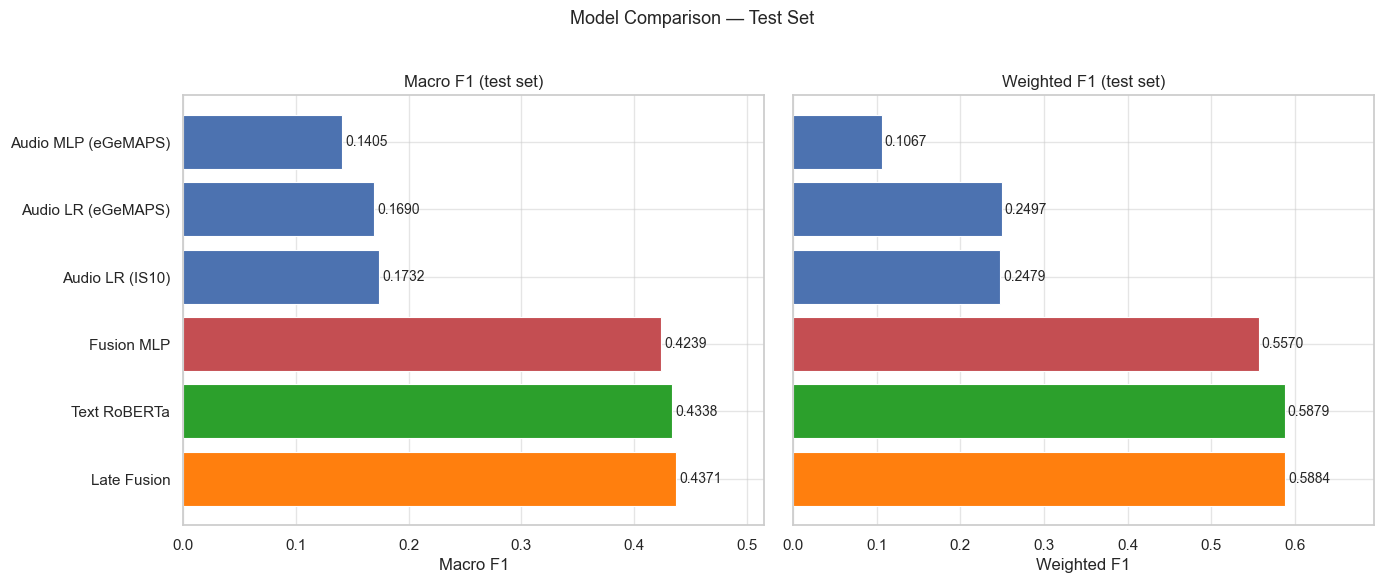

Plot saved → /Users/priyanthvijayasures/Documents/000_Schule/Bachelor Data Science/6. Semester/NLP_Projekte/NLP_P3/outputs/plots/comparison_fusion.png


In [16]:
MODELS_TO_COMPARE = {
    'Audio LR (IS10)':     'audio_lr_is10',
    'Audio LR (eGeMAPS)':  'audio_lr_egemaps',
    'Audio MLP (eGeMAPS)': 'audio_mlp_egemaps',
    'Text RoBERTa':        'text_roberta',
    'Late Fusion':         LATE_TAG,     # multimodal_late_fusion  (weighted avg)
    'Fusion MLP':          TAG,          # multimodal_feature_fusion (concat + MLP)
}

rows = []
for label, tag in MODELS_TO_COMPARE.items():
    p = get_metrics_path(tag)
    if p.exists():
        m = json.loads(p.read_text())
        rows.append({
            'Model':       label,
            'Macro F1':    m['macro_f1'],
            'Weighted F1': m['weighted_f1'],
        })
    else:
        print(f'[skip] {tag} — metrics not found')

df_cmp = pd.DataFrame(rows).sort_values('Macro F1', ascending=False).reset_index(drop=True)
print(df_cmp.to_string(index=False))

FUSION_COLOR  = '#C44E52'
TEXT_COLOR    = '#2CA02C'
LATE_COLOR    = '#FF7F0E'
DEFAULT_COLOR = '#4C72B0'

def bar_color(name):
    if name == 'Fusion MLP':   return FUSION_COLOR
    if name == 'Text RoBERTa': return TEXT_COLOR
    if name == 'Late Fusion':  return LATE_COLOR
    return DEFAULT_COLOR

colors = [bar_color(r) for r in df_cmp['Model']]

fig, axes = plt.subplots(1, 2, figsize=(14, 0.7 * len(df_cmp) + 1.5), sharey=True)

for ax, metric in zip(axes, ['Macro F1', 'Weighted F1']):
    bars = ax.barh(df_cmp['Model'], df_cmp[metric],
                   color=colors, edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, df_cmp[metric]):
        ax.text(
            bar.get_width() + 0.003,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=10,
        )
    ax.set_xlabel(metric)
    ax.set_xlim(0, df_cmp[metric].max() * 1.18)
    ax.set_title(f'{metric} (test set)')
    ax.invert_yaxis()

plt.suptitle('Model Comparison — Test Set', fontsize=13, y=1.02)
plt.tight_layout()

plot_path = OUTPUTS_DIR / 'plots' / 'comparison_fusion.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved → {plot_path}')

### 9b · Full F1 Table — All Models

Heatmap table showing per-class F1 for every trained model, plus Macro F1 and Weighted F1 as summary columns (separated by the thick black vertical line). The thick horizontal line divides audio-only models from text and fusion models.

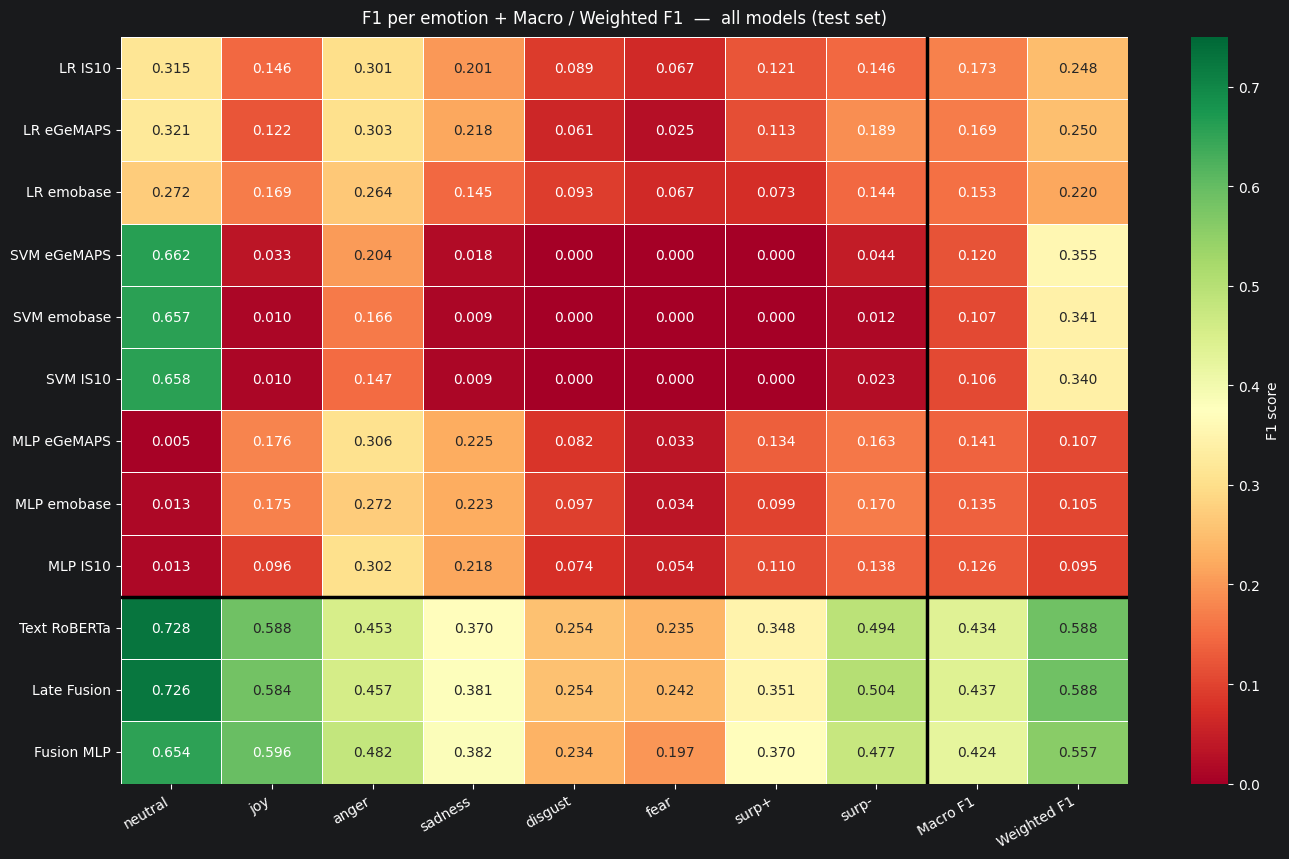

Saved → /Users/priyanthvijayasures/Documents/000_Schule/Bachelor Data Science/6. Semester/NLP_Projekte/NLP_P3/outputs/plots/all_models_f1_table.png


In [17]:
_COL_NAMES = {
    'neutral': 'neutral', 'joy': 'joy', 'anger': 'anger',
    'sadness': 'sadness', 'disgust': 'disgust', 'fear': 'fear',
    'surprise_positive': 'surp+', 'surprise_negative': 'surp-',
}

_ALL_MODELS_TABLE = {
    # ── Audio ──────────────────────────────────────────────────────────────
    'LR IS10':      'audio_lr_is10',
    'LR eGeMAPS':   'audio_lr_egemaps',
    'LR emobase':   'audio_lr_emobase',
    'SVM eGeMAPS':  'audio_svm_egemaps',
    'SVM emobase':  'audio_svm_emobase',
    'SVM IS10':     'audio_svm_is10',
    'MLP eGeMAPS':  'audio_mlp_egemaps',
    'MLP emobase':  'audio_mlp_emobase',
    'MLP IS10':     'audio_mlp_is10',
    # ── Text & fusion ──────────────────────────────────────────────────────
    'Text RoBERTa': 'text_roberta',
    'Late Fusion':  LATE_TAG,
    'Fusion MLP':   TAG,
}
_NON_AUDIO = {'Text RoBERTa', 'Late Fusion', 'Fusion MLP'}

_rows = []
for label, tag in _ALL_MODELS_TABLE.items():
    p = get_metrics_path(tag)
    if not p.exists():
        continue
    m = json.loads(p.read_text())
    row = {'Model': label}
    for c in EMOTION_LABELS:
        row[_COL_NAMES[c]] = m['per_class'][c]['f1']
    row['Macro F1']    = m['macro_f1']
    row['Weighted F1'] = m['weighted_f1']
    _rows.append(row)

_df_tbl   = pd.DataFrame(_rows).set_index('Model')
_n_audio  = sum(1 for r in _rows if r['Model'] not in _NON_AUDIO)

fig, ax = plt.subplots(figsize=(14, 0.6 * len(_df_tbl) + 1.5))
sns.heatmap(
    _df_tbl, annot=True, fmt='.3f', cmap='RdYlGn',
    vmin=0.0, vmax=0.75, linewidths=0.4, ax=ax,
    cbar_kws={'label': 'F1 score'},
)
# Separate per-class columns from summary columns
ax.axvline(x=len(EMOTION_LABELS), color='black', linewidth=2.5)
# Separate audio models from text/fusion models
ax.axhline(y=_n_audio, color='black', linewidth=2.5)
ax.set_title('F1 per emotion + Macro / Weighted F1  —  all models (test set)',
             fontsize=12, pad=10)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()

_tbl_path = OUTPUTS_DIR / 'plots' / 'all_models_f1_table.png'
plt.savefig(_tbl_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {_tbl_path}')